<div style="background:#0f172a;padding:28px 32px;border-radius:12px;margin-bottom:8px">
<h1 style="color:#f8fafc;font-family:monospace;margin:0 0 8px 0">
  ResNet50V2 · CIFAR-10 Fine-Tuning
</h1>
<p style="color:#94a3b8;margin:0;font-size:15px">
  Custom Training Loop &nbsp;·&nbsp; Augmentation-in-Model &nbsp;·&nbsp; AdamW Optimiser
</p>
</div>

### Case Study — 10-Class Image Recognition

| Label | Class | Label | Class |
|-------|-------|-------|-------|
| 0 | ✈️ Airplane | 5 | 🐶 Dog |
| 1 | 🚗 Automobile | 6 | 🐸 Frog |
| 2 | 🐦 Bird | 7 | 🐴 Horse |
| 3 | 🐱 Cat | 8 | 🚢 Ship |
| 4 | 🦌 Deer | 9 | 🚛 Truck |

> **Dataset:** CIFAR-10 — 60 000 images (32×32 px) split 50k train / 10k test.  
> Built into `tf.keras.datasets` — **zero download required.**

---

### Design Choices vs. Standard Approach

| Decision | Reason |
|----------|--------|
| **ResNet50V2** backbone | Skip-connections handle CIFAR's low-res features better than VGG |
| **Augmentation inside model** | Preprocessing layers baked in → portable, inference-safe |
| **Custom `tf.GradientTape` loop** | Full control over gradient clipping + per-step metrics |
| **AdamW** optimiser | Weight decay prevents overfitting on small 32×32 images |
| **96×96 resize** | Minimal upscaling to feed pretrained weights without distortion |

In [5]:
import os, time, json, logging
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Tuple, Dict, Optional, List

import numpy as np
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── reproducibility ──────────────────────────────────────
tf.random.set_seed(0)
np.random.seed(0)

# ── logger ───────────────────────────────────────────────
logging.basicConfig(format="[%(levelname)s %(asctime)s] %(message)s",
                    datefmt="%H:%M:%S", level=logging.INFO)
log = logging.getLogger("cifar_tuner")

# ── GPU memory growth ─────────────────────────────────────
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

log.info("TensorFlow %s", tf.__version__)
log.info("GPUs available: %s", tf.config.list_physical_devices("GPU") or "none — CPU mode")

[INFO 02:49:54] TensorFlow 2.18.0
[INFO 02:49:54] GPUs available: none — CPU mode


## ⚙️ Hyperparameters

All settings are declared once in `HParams`. Change here — everything downstream adapts.

In [6]:
@dataclass
class HParams:
    """
    Frozen hyperparameter container.

    img_size       : Resize target for pretrained ResNet50V2 (min 32, rec 96+).
    num_classes    : 10 for CIFAR-10, 100 for CIFAR-100.
    batch_size     : Mini-batch size. Lower if OOM on GPU.
    warmup_epochs  : Head-only phase — backbone frozen, higher LR safe.
    finetune_epochs: Unfreeze phase — very low LR, backbone adapts slowly.
    warmup_lr      : Initial LR for the classifier head.
    finetune_lr    : Fine-tuning LR — must be << warmup_lr.
    weight_decay   : L2 penalty applied by AdamW.
    unfreeze_from  : Negative index; layers at >= this index are unfrozen.
    label_smoothing: Reduces overconfidence, improves generalisation.
    clip_norm      : Gradient clipping threshold.
    out_dir        : Where models, logs, and plots are written.
    """
    img_size        : int   = 96
    num_classes     : int   = 10
    batch_size      : int   = 128
    warmup_epochs   : int   = 12
    finetune_epochs : int   = 12
    warmup_lr       : float = 3e-4
    finetune_lr     : float = 5e-6
    weight_decay    : float = 1e-4
    unfreeze_from   : int   = -20
    label_smoothing : float = 0.1
    clip_norm       : float = 1.0
    out_dir         : str   = "runs/cifar10"

    def dump(self, path: str) -> None:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w") as f:
            json.dump(asdict(self), f, indent=2)

    @classmethod
    def restore(cls, path: str) -> "HParams":
        with open(path) as f:
            return cls(**json.load(f))


hp = HParams()
Path(hp.out_dir).mkdir(parents=True, exist_ok=True)
hp.dump(f"{hp.out_dir}/hparams.json")
log.info("HParams: %s", hp)

[INFO 02:49:54] HParams: HParams(img_size=96, num_classes=10, batch_size=128, warmup_epochs=12, finetune_epochs=12, warmup_lr=0.0003, finetune_lr=5e-06, weight_decay=0.0001, unfreeze_from=-20, label_smoothing=0.1, clip_norm=1.0, out_dir='runs/cifar10')


## 📦 Data Loading
CIFAR-10 is shipped with Keras — no download, no folder setup.  
Images are resized from 32×32 to `img_size × img_size` on-the-fly inside `tf.data`.

In [7]:
CIFAR10_LABELS = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog",      "frog",       "horse","ship","truck",
]
CIFAR100_SUPERCLASS = None   # populated if num_classes == 100


def load_cifar(hp: HParams) -> Tuple[tf.data.Dataset, tf.data.Dataset]:
    """
    Load CIFAR-10 or CIFAR-100 and return (train_ds, test_ds) as
    batched, prefetched tf.data.Dataset objects.

    Preprocessing
    -------------
    - Resize 32×32 → img_size×img_size  (bilinear, anti-alias)
    - Normalise pixel values to [0, 1]
    - One-hot encode labels
    - Training set: cache → shuffle(50 000) → batch → prefetch
    - Test set    : cache → batch → prefetch  (no shuffle)

    Note: Augmentation is baked into the model, NOT here, so the
    test set receives clean images regardless of training augmentation.
    """
    global CIFAR100_SUPERCLASS

    if hp.num_classes == 10:
        (x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar10.load_data()
    elif hp.num_classes == 100:
        (x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar100.load_data(label_mode="fine")
    else:
        raise ValueError(f"num_classes must be 10 or 100, got {hp.num_classes}")

    target = (hp.img_size, hp.img_size)

    def _prep(x, y, is_train: bool) -> tf.data.Dataset:
        ds = tf.data.Dataset.from_tensor_slices((x, y))
        ds = ds.map(
            lambda img, lbl: (
                tf.image.resize(tf.cast(img, tf.float32) / 255.0, target,
                                method="bilinear", antialias=True),
                tf.one_hot(tf.squeeze(lbl), hp.num_classes),
            ),
            num_parallel_calls=tf.data.AUTOTUNE,
        )
        if is_train:
            ds = ds.cache().shuffle(50_000, seed=0)
        else:
            ds = ds.cache()
        return ds.batch(hp.batch_size).prefetch(tf.data.AUTOTUNE)

    train_ds = _prep(x_tr, y_tr, is_train=True)
    test_ds  = _prep(x_te, y_te, is_train=False)

    log.info("CIFAR-%d loaded | train=%d  test=%d  resize=%s",
             hp.num_classes, len(x_tr), len(x_te), target)
    return train_ds, test_ds


train_ds, test_ds = load_cifar(hp)
log.info("Train batches: %d  |  Test batches: %d",
         sum(1 for _ in train_ds), sum(1 for _ in test_ds))

[INFO 02:49:59] CIFAR-10 loaded | train=50000  test=10000  resize=(96, 96)
[INFO 02:50:13] Train batches: 391  |  Test batches: 79


## 🖼️ Sample Images

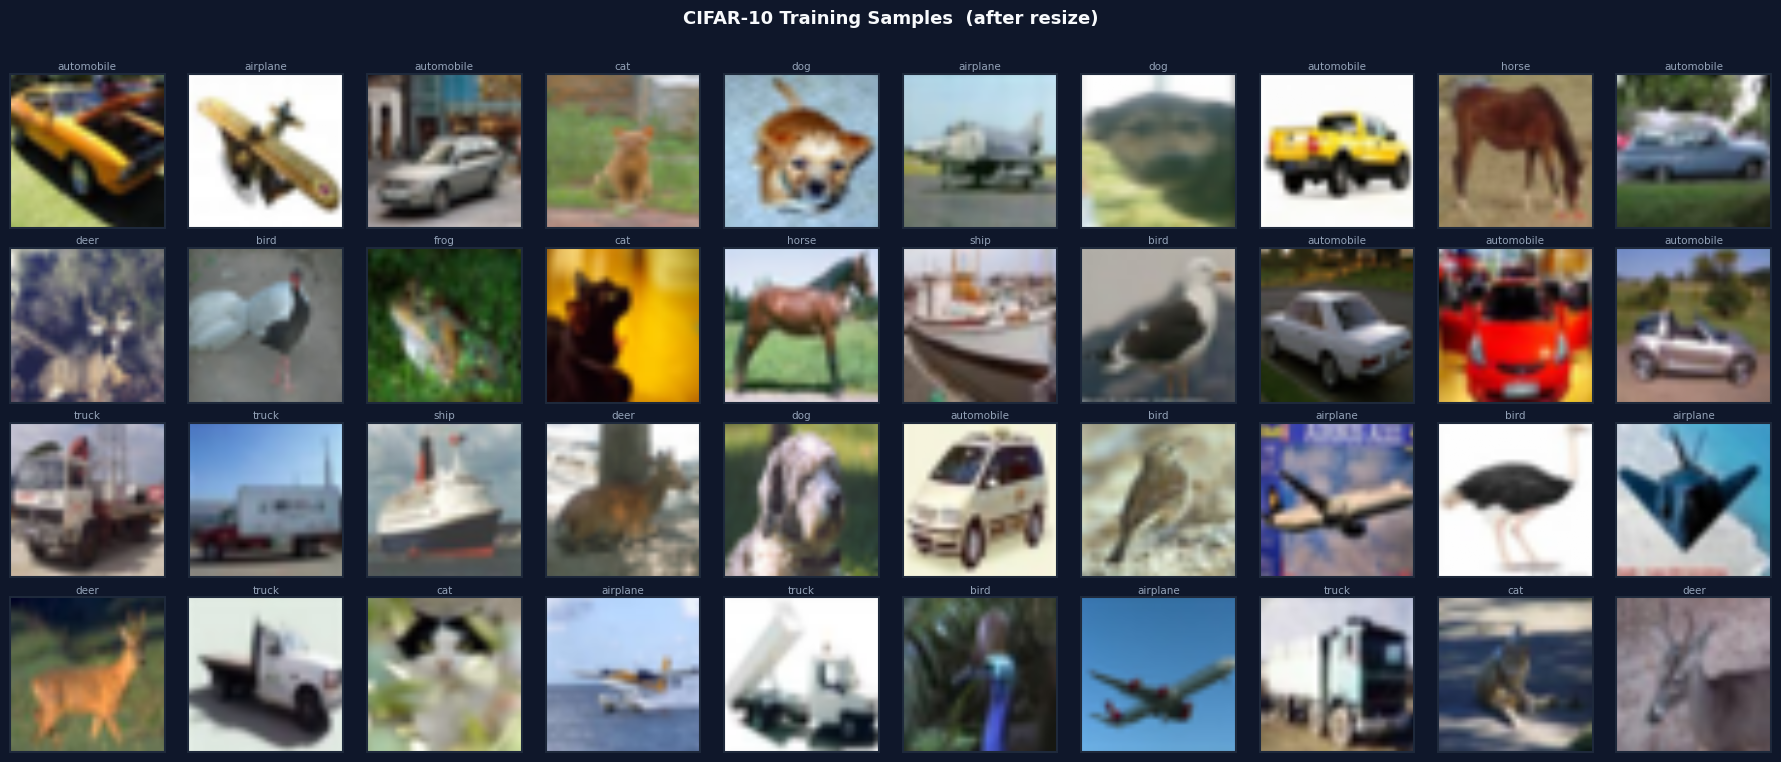

In [8]:
# Pull one batch and display
sample_imgs, sample_lbls = next(iter(train_ds))

fig, axes = plt.subplots(4, 10, figsize=(18, 7.5))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("CIFAR-10 Training Samples  (after resize)",
             color="#f8fafc", fontsize=13, fontweight="bold", y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i].numpy(), interpolation="bilinear")
    ax.set_xticks([]); ax.set_yticks([])
    cls_idx = int(tf.argmax(sample_lbls[i]))
    ax.set_title(CIFAR10_LABELS[cls_idx], color="#94a3b8",
                 fontsize=7.5, pad=3)
    for sp in ax.spines.values():
        sp.set_edgecolor("#1e293b"); sp.set_linewidth(1.5)

plt.tight_layout()
plt.savefig(f"{hp.out_dir}/sample_images.png", dpi=130,
            bbox_inches="tight", facecolor="#0f172a")
plt.show()

## 🏗️ Model Architecture

The classifier is implemented as a **subclassed `tf.keras.Model`**, which bundles:

1. An **augmentation head** (active only during training via `training=True`)
2. The frozen **ResNet50V2 backbone** (ImageNet weights, no top)
3. A lightweight **classifier neck**: GAP → Dense → BN → Dropout → Softmax

```
Input (96×96×3)
    ↓
[TRAIN ONLY] RandomFlip · RandomTranslation · RandomZoom · RandomContrast
    ↓
ResNet50V2 backbone  (frozen in Phase 1, partially unfrozen in Phase 2)
    ↓
GlobalAveragePooling2D
    ↓
Dense(512, GELU)  →  BatchNorm  →  Dropout(0.35)
    ↓
Dense(num_classes, Softmax)
```

In [9]:
class ResNetCIFARClassifier(tf.keras.Model):
    """
    Subclassed transfer-learning model for CIFAR classification.

    The augmentation pipeline is embedded as Keras preprocessing layers
    so the *same* model object is used for both training and inference;
    augmentation is automatically disabled at test time via `training=False`.

    Parameters
    ----------
    hp : HParams object containing all configuration.
    """

    def __init__(self, hp: HParams, **kwargs):
        super().__init__(**kwargs)
        self.hp = hp

        # ── Augmentation layers (applied only when training=True) ──────────
        self.aug = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomTranslation(0.12, 0.12,
                                              fill_mode="reflect"),
            tf.keras.layers.RandomZoom((-0.12, 0.12)),
            tf.keras.layers.RandomContrast(0.15),
        ], name="augmentation")

        # ── ResNet50V2 backbone (no top, no pooling) ───────────────────────
        self.backbone = tf.keras.applications.ResNet50V2(
            include_top = False,
            weights     = "imagenet",
            pooling     = None,
            input_shape = (hp.img_size, hp.img_size, 3),
        )
        self.backbone.trainable = False    # Phase 1: frozen

        # ── Classifier neck ────────────────────────────────────────────────
        self.gap     = tf.keras.layers.GlobalAveragePooling2D()
        self.dense1  = tf.keras.layers.Dense(512, activation=tf.keras.activations.gelu,
                                              name="neck_dense")
        self.bn1     = tf.keras.layers.BatchNormalization(name="neck_bn")
        self.drop1   = tf.keras.layers.Dropout(0.35)
        self.head    = tf.keras.layers.Dense(hp.num_classes, activation="softmax",
                                              name="head")

    def call(self, x, training=False):
        if training:
            x = self.aug(x, training=True)
        x = self.backbone(x, training=False)   # BN in inference mode always
        x = self.gap(x)
        x = self.dense1(x)
        x = self.bn1(x, training=training)
        x = self.drop1(x, training=training)
        return self.head(x)

    def freeze_backbone(self) -> None:
        self.backbone.trainable = False
        log.info("Backbone frozen (%d layers).", len(self.backbone.layers))

    def unfreeze_top(self, from_idx: Optional[int] = None) -> None:
        """Unlock the tail layers for Phase 2 fine-tuning."""
        idx = from_idx or self.hp.unfreeze_from
        self.backbone.trainable = True
        for layer in self.backbone.layers[:idx]:
            layer.trainable = False
        n = sum(1 for l in self.backbone.layers if l.trainable)
        log.info("Phase 2 — %d / %d backbone layers now trainable.",
                 n, len(self.backbone.layers))

    def trainable_summary(self) -> None:
        rows = [(l.name, l.__class__.__name__, l.trainable)
                for l in self.backbone.layers]
        header = f"  {'Layer':<40} {'Type':<24} Trainable"
        sep    = "  " + "─" * 70
        lines  = [header, sep]
        for name, cls, trn in rows:
            lines.append(f"  {name:<40} {cls:<24} {'✓' if trn else '✗'}")
        log.info("Backbone trainability:\n%s", "\n".join(lines))


clf = ResNetCIFARClassifier(hp, name="ResNet50V2_CIFAR10")

# Warm-up call to build weights
dummy = tf.zeros((1, hp.img_size, hp.img_size, 3))
_ = clf(dummy, training=False)

total     = clf.count_params()
trainable = sum(tf.size(w).numpy() for w in clf.trainable_weights)
log.info("Model ready — total params: %s  |  trainable: %s",
         f"{total:,}", f"{trainable:,}")
clf.summary()

c:\Users\HELAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'ResNet50V2_CIFAR10', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
[INFO 02:50:24] Model ready — total params: 24,621,066  |  trainable: 1,055,242


Model: "ResNet50V2_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 3, 3, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neck_dense (Dense)              │ (1, 512)               │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neck_bn (BatchNormalization)    │ (1, 512)               │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (1, 10)                │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,621,066 (93.92 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 23,565,824 (89.90 MB)

## 🔁 Custom Training Loop

Rather than `.fit()`, we use `tf.GradientTape` directly.  
This gives us:
- **Per-step gradient clipping** (`clip_by_global_norm`)
- **Epoch-level metric dicts** stored for later plotting
- **Explicit LR injection** so Phase 2 gets a fresh lower rate immediately

In [10]:
class Trainer:
    """
    Manages both training phases using tf.GradientTape.

    Attributes
    ----------
    model    : ResNetCIFARClassifier instance
    hp       : HParams instance
    history  : dict accumulating per-epoch metrics across both phases
    """

    def __init__(self, model: ResNetCIFARClassifier, hp: HParams):
        self.model   = model
        self.hp      = hp
        self.history : Dict[str, List[float]] = {
            "loss": [], "accuracy": [], "val_loss": [], "val_accuracy": [],
            "lr":   [], "phase":    [],
        }
        self._loss_fn = tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=hp.label_smoothing
        )
        self._opt = None    # set per phase

    # ── public ──────────────────────────────────────────────────────────────
    def run_phase1(self) -> None:
        """
        Phase 1 — Warmup
        Backbone is frozen.  Only the classifier neck trains.
        Higher learning rate is safe because these weights are randomly
        initialised and won't damage ImageNet features.
        """
        log.info("━" * 62)
        log.info("PHASE 1  |  Warmup  |  lr=%.1e  |  backbone frozen",
                 self.hp.warmup_lr)
        log.info("━" * 62)
        self.model.freeze_backbone()
        self.model.trainable_summary()
        self._opt = tf.keras.optimizers.AdamW(
            learning_rate = self.hp.warmup_lr,
            weight_decay  = self.hp.weight_decay,
        )
        self._run_epochs(self.hp.warmup_epochs, phase_tag=1)

    def run_phase2(self) -> None:
        """
        Phase 2 — Fine-tuning
        Unlock the last N ResNet50V2 layers and train at a much lower LR
        to gradually adapt high-level representations to CIFAR semantics
        without destroying the generalised ImageNet features.
        """
        log.info("━" * 62)
        log.info("PHASE 2  |  Fine-tuning  |  lr=%.1e  |  top layers unfrozen",
                 self.hp.finetune_lr)
        log.info("━" * 62)
        self.model.unfreeze_top(self.hp.unfreeze_from)
        self.model.trainable_summary()
        # Recompile with lower LR — must reassign optimiser
        self._opt = tf.keras.optimizers.AdamW(
            learning_rate = self.hp.finetune_lr,
            weight_decay  = self.hp.weight_decay,
        )
        self._run_epochs(self.hp.finetune_epochs, phase_tag=2)

    # ── private ─────────────────────────────────────────────────────────────
    def _run_epochs(self, n_epochs: int, phase_tag: int) -> None:
        for epoch in range(1, n_epochs + 1):
            t0           = time.perf_counter()
            tr_loss, tr_acc = self._train_epoch()
            va_loss, va_acc = self._eval_epoch()
            elapsed      = time.perf_counter() - t0

            current_lr = float(self._opt.learning_rate)
            self.history["loss"].append(tr_loss)
            self.history["accuracy"].append(tr_acc)
            self.history["val_loss"].append(va_loss)
            self.history["val_accuracy"].append(va_acc)
            self.history["lr"].append(current_lr)
            self.history["phase"].append(phase_tag)

            log.info(
                "Phase %d  Epoch %2d/%d  |  loss %.4f  acc %.4f  |  "
                "val_loss %.4f  val_acc %.4f  |  %.1fs",
                phase_tag, epoch, n_epochs,
                tr_loss, tr_acc, va_loss, va_acc, elapsed,
            )

    @tf.function
    def _train_step(self, x, y):
        with tf.GradientTape() as tape:
            logits = self.clf(x, training=True)
            loss   = self._loss_fn(y, logits)
        grads = tape.gradient(loss, self.clf.trainable_variables)
        grads, _norm = tf.clip_by_global_norm(grads, self.hp.clip_norm)
        self._opt.apply_gradients(zip(grads, self.clf.trainable_variables))
        acc = tf.reduce_mean(
            tf.cast(tf.equal(tf.argmax(logits, 1), tf.argmax(y, 1)), tf.float32)
        )
        return loss, acc

    def _train_epoch(self) -> Tuple[float, float]:
        losses, accs = [], []
        for x_batch, y_batch in train_ds:
            l, a = self._train_step_call(x_batch, y_batch)
            losses.append(float(l)); accs.append(float(a))
        return float(np.mean(losses)), float(np.mean(accs))

    def _train_step_call(self, x, y):
        with tf.GradientTape() as tape:
            logits = self.model(x, training=True)
            loss   = self._loss_fn(y, logits)
        grads = tape.gradient(loss, self.model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, self.hp.clip_norm)
        self._opt.apply_gradients(zip(grads, self.model.trainable_variables))
        acc = tf.reduce_mean(
            tf.cast(tf.equal(tf.argmax(logits, 1), tf.argmax(y, 1)), tf.float32))
        return loss, acc

    def _eval_epoch(self) -> Tuple[float, float]:
        losses, accs = [], []
        for x_batch, y_batch in test_ds:
            logits = self.model(x_batch, training=False)
            loss   = self._loss_fn(y_batch, logits)
            acc    = tf.reduce_mean(
                tf.cast(tf.equal(tf.argmax(logits, 1), tf.argmax(y_batch, 1)),
                        tf.float32))
            losses.append(float(loss)); accs.append(float(acc))
        return float(np.mean(losses)), float(np.mean(accs))

    def save_history(self) -> None:
        path = f"{self.hp.out_dir}/history.json"
        with open(path, "w") as f:
            json.dump(self.history, f, indent=2)
        log.info("History saved -> %s", path)


trainer = Trainer(clf, hp)
log.info("Trainer ready")

[INFO 02:50:24] Trainer ready


## 🔒 Phase 1 · Warmup Training
Backbone locked → only the custom head trains.

In [ ]:
trainer.run_phase1()
p1_best = max(
    v for v, p in zip(trainer.history["val_accuracy"], trainer.history["phase"])
    if p == 1
)
log.info("Phase 1 best val_acc: %.4f", p1_best)

## 🔓 Phase 2 · Fine-Tuning
Top backbone layers unlocked — learning rate dropped to `5e-6`.

In [ ]:
trainer.run_phase2()
trainer.save_history()
p2_best = max(
    v for v, p in zip(trainer.history["val_accuracy"], trainer.history["phase"])
    if p == 2
)
log.info("Phase 2 best val_acc: %.4f", p2_best)
log.info("Overall best val_acc: %.4f", max(trainer.history["val_accuracy"]))

## 📊 Evaluation & Visualisation

In [13]:
DARK_BG  = "#0f172a"
CARD_BG  = "#1e293b"
TXT_PRI  = "#f1f5f9"
TXT_SEC  = "#94a3b8"
ACCENT1  = "#38bdf8"   # sky-400
ACCENT2  = "#fb923c"   # orange-400
ACCENT3  = "#a78bfa"   # violet-400
DIVIDER  = "#475569"


class Visualiser:
    """
    All plotting for the CIFAR fine-tuning notebook.

    Dark-theme aesthetic is intentional to distinguish this notebook from
    other pipelines that use light matplotlib defaults.

    Methods
    -------
    training_curves()       ->  3-panel: loss, accuracy, LR schedule
    confusion_heatmap()     ->  normalised confusion matrix
    per_class_f1_bars()     ->  horizontal bar chart of per-class F1 scores
    misclassified_grid()    ->  mosaic of wrong predictions with true/pred labels
    """

    def __init__(self, model, hp: HParams, history: dict):
        self.model   = model
        self.hp      = hp
        self.history = history
        self._apply_dark_theme()

    # ── public ──────────────────────────────────────────────────────────────
    def training_curves(self, save_path: Optional[str] = None) -> None:
        """
        3-panel training dashboard:
          Left   → Loss (train vs val)
          Centre → Accuracy (train vs val)  with phase-boundary annotation
          Right  → Learning Rate on log scale
        """
        H    = self.history
        eps  = list(range(1, len(H["loss"]) + 1))
        p1   = sum(1 for p in H["phase"] if p == 1)   # phase-1 length

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        fig.patch.set_facecolor(DARK_BG)
        fig.suptitle("ResNet50V2 · CIFAR-10 · Training Dashboard",
                     color=TXT_PRI, fontsize=14, fontweight="bold")

        # ── Loss ────────────────────────────────────────────────────────────
        ax1.plot(eps, H["loss"],     color=ACCENT1, lw=2, label="Train")
        ax1.plot(eps, H["val_loss"], color=ACCENT2, lw=2, ls="--", label="Val")
        self._phase_divider(ax1, p1, eps)
        ax1.set_title("Loss", color=TXT_PRI)
        ax1.set_xlabel("Epoch", color=TXT_SEC)
        ax1.legend(facecolor=CARD_BG, labelcolor=TXT_SEC, fontsize=9)
        ax1.grid(True, alpha=0.15, color=DIVIDER)

        # ── Accuracy ─────────────────────────────────────────────────────────
        ax2.plot(eps, H["accuracy"],     color=ACCENT1, lw=2, label="Train")
        ax2.plot(eps, H["val_accuracy"], color=ACCENT2, lw=2, ls="--", label="Val")
        self._phase_divider(ax2, p1, eps)
        best_e = int(np.argmax(H["val_accuracy"])) + 1
        best_v = max(H["val_accuracy"])
        ax2.annotate(f" best {best_v:.3f}",
                     xy=(best_e, best_v), xytext=(best_e + 0.5, best_v - 0.04),
                     color=ACCENT3, fontsize=9,
                     arrowprops=dict(arrowstyle="->", color=ACCENT3, lw=1))
        ax2.set_title("Accuracy", color=TXT_PRI)
        ax2.set_xlabel("Epoch", color=TXT_SEC)
        ax2.set_ylim(0, 1.05)
        ax2.legend(facecolor=CARD_BG, labelcolor=TXT_SEC, fontsize=9)
        ax2.grid(True, alpha=0.15, color=DIVIDER)

        # ── LR schedule ───────────────────────────────────────────────────────
        ax3.semilogy(eps, H["lr"], color=ACCENT3, lw=2)
        self._phase_divider(ax3, p1, eps)
        ax3.set_title("Learning Rate", color=TXT_PRI)
        ax3.set_xlabel("Epoch", color=TXT_SEC)
        ax3.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax3.grid(True, which="both", alpha=0.15, color=DIVIDER)

        for ax in (ax1, ax2, ax3):
            ax.set_facecolor(CARD_BG)
            ax.tick_params(colors=TXT_SEC)
            for sp in ax.spines.values():
                sp.set_edgecolor(DIVIDER)

        plt.tight_layout()
        path = save_path or f"{self.hp.out_dir}/training_curves.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=DARK_BG)
        plt.show()
        log.info("Training curves -> %s", path)

    def confusion_heatmap(self, save_path: Optional[str] = None) -> np.ndarray:
        """
        Normalised confusion matrix using a custom dark-mode colormap.
        Diagonal = recall per class.  Off-diagonal = confusion pairs.
        """
        y_true, y_pred = self._collect_preds()
        cm     = confusion_matrix(y_true, y_pred, normalize="true")
        labels = CIFAR10_LABELS[:self.hp.num_classes]

        cmap = LinearSegmentedColormap.from_list(
            "dark_sky", [DARK_BG, "#0ea5e9", "#f0f9ff"]
        )
        fig, ax = plt.subplots(figsize=(10, 8))
        fig.patch.set_facecolor(DARK_BG)
        ax.set_facecolor(DARK_BG)

        im = ax.imshow(cm * 100, cmap=cmap, aspect="auto", vmin=0, vmax=100)
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Recall (%)", color=TXT_SEC, fontsize=10)
        cbar.ax.yaxis.set_tick_params(color=TXT_SEC)
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TXT_SEC)

        for i in range(len(labels)):
            for j in range(len(labels)):
                val   = cm[i, j] * 100
                color = TXT_PRI if val < 55 else DARK_BG
                ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                        fontsize=8, color=color)

        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=35,
                                                               ha="right", color=TXT_SEC, fontsize=9)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, color=TXT_SEC, fontsize=9)
        ax.set_xlabel("Predicted", color=TXT_SEC, fontsize=11)
        ax.set_ylabel("True Label", color=TXT_SEC, fontsize=11)
        ax.set_title("Confusion Matrix — CIFAR-10 (normalised)",
                     color=TXT_PRI, fontsize=13, fontweight="bold", pad=14)
        for sp in ax.spines.values(): sp.set_visible(False)

        plt.tight_layout()
        path = save_path or f"{self.hp.out_dir}/confusion_matrix.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=DARK_BG)
        plt.show()
        log.info("Confusion heatmap -> %s", path)
        return cm

    def per_class_f1_bars(self, save_path: Optional[str] = None) -> None:
        """
        Horizontal bars showing per-class F1-score with colour encoding:
          Green  ( F1 >= 0.85 ) · Yellow ( 0.7–0.85 ) · Red ( < 0.7 )
        """
        y_true, y_pred = self._collect_preds()
        labels    = CIFAR10_LABELS[:self.hp.num_classes]
        report    = classification_report(y_true, y_pred, target_names=labels,
                                          output_dict=True)
        f1_scores = [report[c]["f1-score"] for c in labels]
        colors    = [
            "#22c55e" if s >= 0.85 else "#eab308" if s >= 0.70 else "#ef4444"
            for s in f1_scores
        ]

        fig, ax = plt.subplots(figsize=(9, 5))
        fig.patch.set_facecolor(DARK_BG)
        ax.set_facecolor(CARD_BG)

        bars = ax.barh(labels[::-1], [s * 100 for s in f1_scores[::-1]],
                       color=colors[::-1], edgecolor=DARK_BG, linewidth=0.5)
        for bar, val in zip(bars, f1_scores[::-1]):
            ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", color=TXT_SEC, fontsize=9)

        ax.axvline(85, color="#22c55e", ls=":", lw=1.2, alpha=0.6, label="85% threshold")
        ax.axvline(70, color="#eab308", ls=":", lw=1.2, alpha=0.6, label="70% threshold")
        ax.set_xlim(0, 110)
        ax.set_xlabel("F1-Score (%)", color=TXT_SEC)
        ax.set_title("Per-Class F1 Score", color=TXT_PRI, fontsize=13, fontweight="bold")
        ax.tick_params(colors=TXT_SEC)
        for sp in ax.spines.values(): sp.set_edgecolor(DIVIDER)
        ax.legend(facecolor=CARD_BG, labelcolor=TXT_SEC, fontsize=8, loc="lower right")

        plt.tight_layout()
        path = save_path or f"{self.hp.out_dir}/f1_per_class.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=DARK_BG)
        plt.show()
        log.info("F1 bar chart -> %s", path)

    def misclassified_grid(self, n: int = 20, save_path: Optional[str] = None) -> None:
        """
        Display n randomly sampled misclassified images.
        Title line shows: True label  →  Predicted (confidence %)
        """
        wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []

        for x_batch, y_batch in test_ds:
            probs   = self.model(x_batch, training=False).numpy()
            preds   = np.argmax(probs, axis=1)
            trues   = np.argmax(y_batch.numpy(), axis=1)
            mask    = preds != trues
            wrong_imgs.extend(x_batch.numpy()[mask])
            wrong_pred.extend(preds[mask])
            wrong_true.extend(trues[mask])
            wrong_conf.extend(np.max(probs, axis=1)[mask])
            if len(wrong_imgs) >= n:
                break

        idx  = np.random.choice(len(wrong_imgs), size=min(n, len(wrong_imgs)), replace=False)
        cols = 5
        rows = int(np.ceil(len(idx) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.4))
        fig.patch.set_facecolor(DARK_BG)
        fig.suptitle("Misclassified Samples", color=TXT_PRI,
                     fontsize=13, fontweight="bold", y=1.01)

        labels = CIFAR10_LABELS[:self.hp.num_classes]
        for ax, i in zip(axes.flat, idx):
            ax.imshow(wrong_imgs[i], interpolation="bilinear")
            ax.set_facecolor(CARD_BG)
            for sp in ax.spines.values():
                sp.set_edgecolor("#ef4444"); sp.set_linewidth(2.5)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(
                f"✓ {labels[wrong_true[i]]}",
                color="#22c55e", fontsize=8, pad=2,
            )
            ax.set_xlabel(
                f"✗ {labels[wrong_pred[i]]}  {wrong_conf[i]:.0%}",
                color="#ef4444", fontsize=8,
            )
        for ax in axes.flat[len(idx):]:
            ax.axis("off")

        plt.tight_layout()
        path = save_path or f"{self.hp.out_dir}/misclassified.png"
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=DARK_BG)
        plt.show()
        log.info("Misclassified grid -> %s", path)

    # ── private ──────────────────────────────────────────────────────────────
    def _collect_preds(self) -> Tuple[np.ndarray, np.ndarray]:
        y_true, y_pred = [], []
        for x_b, y_b in test_ds:
            probs  = self.model(x_b, training=False).numpy()
            y_pred.extend(np.argmax(probs, axis=1))
            y_true.extend(np.argmax(y_b.numpy(), axis=1))
        return np.array(y_true), np.array(y_pred)

    @staticmethod
    def _apply_dark_theme() -> None:
        plt.rcParams.update({
            "figure.facecolor": DARK_BG, "axes.facecolor": CARD_BG,
            "axes.edgecolor":   DIVIDER,  "text.color":      TXT_PRI,
            "axes.labelcolor":  TXT_SEC,  "xtick.color":     TXT_SEC,
            "ytick.color":      TXT_SEC,  "grid.color":      DIVIDER,
            "legend.facecolor": CARD_BG,  "legend.edgecolor":DIVIDER,
        })

    @staticmethod
    def _phase_divider(ax, split: int, eps: list) -> None:
        ax.axvline(split + 0.5, color=DIVIDER, ls="--", lw=1.4, label="Phase 1│2")
        ax.axvspan(1,            split + 0.5,  alpha=0.06, color=ACCENT1)
        ax.axvspan(split + 0.5, max(eps),      alpha=0.06, color=ACCENT2)


viz = Visualiser(clf, hp, trainer.history)
log.info("Visualiser ready")

[INFO 03:01:02] Visualiser ready


### 📈 Training Curves

In [ ]:
viz.training_curves()

### 🔲 Confusion Matrix

In [ ]:
_ = viz.confusion_heatmap()

### 📊 Per-Class F1 Scores

In [ ]:
viz.per_class_f1_bars()

# Full classification report
y_true, y_pred = viz._collect_preds()
print(classification_report(
    y_true, y_pred,
    target_names=CIFAR10_LABELS[:hp.num_classes],
    digits=4,
))

### ❌ Misclassified Samples
Red border · Top line = **true label** · Bottom line = **predicted + confidence**

In [ ]:
viz.misclassified_grid(n=20)

## 💾 Save & Reload

In [ ]:
save_path = f"{hp.out_dir}/resnet50v2_cifar10.keras"
clf.save(save_path)
log.info("Model saved -> %s", save_path)

## 🔍 Inference on a Single Image

```python
# Usage example
result = predict_single(clf, hp, "path/to/your_image.png")
```

In [ ]:
def predict_single(
    model     : ResNetCIFARClassifier,
    hp        : HParams,
    img_source,   # file path (str) OR numpy array (H×W×3, uint8 or float32)
) -> Dict[str, float]:
    """
    Classify one image and render a dark-theme confidence bar chart.

    Parameters
    ----------
    img_source : path to an image file, or a (H, W, 3) numpy array.

    Returns
    -------
    dict  {'class_name': probability, ...}  sorted descending.
    """
    # ── Load ──────────────────────────────────────────────────────────────
    if isinstance(img_source, str):
        raw = tf.keras.utils.load_img(img_source,
                                       target_size=(hp.img_size, hp.img_size))
        arr = tf.keras.utils.img_to_array(raw) / 255.0
    else:
        arr = tf.image.resize(
            tf.cast(img_source, tf.float32) / (255.0 if img_source.dtype == np.uint8 else 1.0),
            (hp.img_size, hp.img_size),
        ).numpy()

    # ── Predict ───────────────────────────────────────────────────────────
    probs   = model(arr[None], training=False).numpy()[0]
    labels  = CIFAR10_LABELS[:hp.num_classes]
    result  = dict(sorted({l: round(float(p), 5) for l, p in zip(labels, probs)}.items(),
                           key=lambda x: x[1], reverse=True))
    top_cls = next(iter(result))

    # ── Visualise ─────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4))
    fig.patch.set_facecolor(DARK_BG)

    ax_img.imshow(arr, interpolation="bilinear")
    ax_img.axis("off")
    ax_img.set_title(f"{top_cls.upper()}  ·  {result[top_cls]:.1%}",
                     color=ACCENT1, fontsize=13, fontweight="bold", pad=8)
    for sp in ax_img.spines.values():
        sp.set_edgecolor(ACCENT1); sp.set_linewidth(2)

    sorted_labels = list(result.keys())[::-1]
    sorted_probs  = [result[k] * 100 for k in sorted_labels]
    bar_colors    = [ACCENT1 if k == top_cls else TXT_SEC for k in sorted_labels]
    ax_bar.barh(sorted_labels, sorted_probs, color=bar_colors,
                edgecolor=DARK_BG, linewidth=0.4)
    ax_bar.set_xlim(0, 110)
    ax_bar.set_xlabel("Probability (%)", color=TXT_SEC)
    ax_bar.set_title("Confidence Distribution", color=TXT_PRI, fontweight="bold")
    ax_bar.set_facecolor(CARD_BG)
    ax_bar.tick_params(colors=TXT_SEC)
    for sp in ax_bar.spines.values(): sp.set_edgecolor(DIVIDER)
    ax_bar.grid(True, axis="x", alpha=0.15, color=DIVIDER)

    plt.tight_layout()
    plt.savefig(f"{hp.out_dir}/inference_result.png", dpi=130,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    return result


# ── Demo: take one test image directly from the dataset ──────────────────
demo_imgs, demo_lbls = next(iter(test_ds))
demo_img  = (demo_imgs[0].numpy() * 255).astype(np.uint8)
true_lbl  = CIFAR10_LABELS[int(tf.argmax(demo_lbls[0]))]
print(f"True label: {true_lbl}")
result = predict_single(clf, hp, demo_img)
print("Prediction:", result)

## 🔄 Reload Saved Model

In [ ]:
# Restore a previously saved model
# loaded = tf.keras.models.load_model("runs/cifar10/resnet50v2_cifar10.keras")
# loaded_hp = HParams.restore("runs/cifar10/hparams.json")
# result = predict_single(loaded, loaded_hp, demo_img)
print("💡 Uncomment lines above to restore a saved checkpoint")